# Simple Image Segmentation Training Notebook

This notebook uses **classical image processing** for segmentation:
- Grayscale conversion
- Thresholding (Otsu)
- Morphology (opening/closing)
- Connected components

**No deep learning used.**

## Step 1: Import libraries

In [27]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import kagglehub

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

## Step 2: Download/load dataset

In [28]:
DOWNLOAD_DIR = Path(kagglehub.dataset_download("nizier193/leaf-segmentation-dataset-mk7"))
DATASET_DIR = DOWNLOAD_DIR / "aug"

IMAGE_DIR = DATASET_DIR / "images"
MASK_DIR = DATASET_DIR / "masks"

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)
print("Images:", len(list(IMAGE_DIR.glob("*"))))
print("Masks:", len(list(MASK_DIR.glob("*"))))

IMAGE_DIR: /home/okaryn/.cache/kagglehub/datasets/nizier193/leaf-segmentation-dataset-mk7/versions/1/aug/images
MASK_DIR : /home/okaryn/.cache/kagglehub/datasets/nizier193/leaf-segmentation-dataset-mk7/versions/1/aug/masks
Images: 552
Masks: 552


## Step 3: Helper functions

In [29]:
def read_image(path, size=(256, 256)):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def read_mask(path, size=(256, 256)):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask

def show_many(images, titles, cols=3, size=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=size)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray" if len(img.shape) == 2 else None)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## Step 4: Build image-mask pairs

In [30]:
image_files = sorted(IMAGE_DIR.glob("*"))
mask_files = sorted(MASK_DIR.glob("*"))

pairs = list(zip(image_files, mask_files))
print(f"Pairs found: {len(pairs)}")

Pairs found: 552


## Step 5: Preview one image

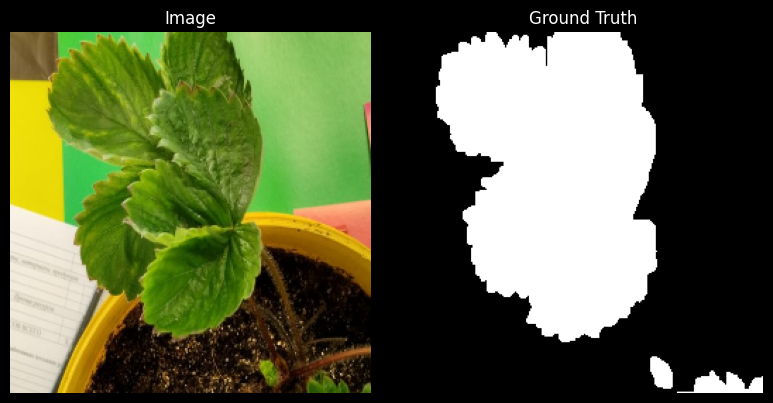

In [31]:
img_path, mask_path = pairs[0]
img = read_image(img_path)
gt = read_mask(mask_path)

show_many([img, gt], ["Image", "Ground Truth"], cols=2, size=(8, 4))

## Step 6: Simple segmentation method

In [32]:
def largest_component(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = 1 + np.argmax(areas)
    out = np.zeros_like(binary)
    out[labels == largest_idx] = 255
    return out

def segment_simple(image, kernel_size=(5, 5), invert=True):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh_type = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, mask = cv2.threshold(blur, 0, 255, thresh_type + cv2.THRESH_OTSU)

    kernel = np.ones(kernel_size, np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return gray, blur, mask

## Step 7: Apply segmentation

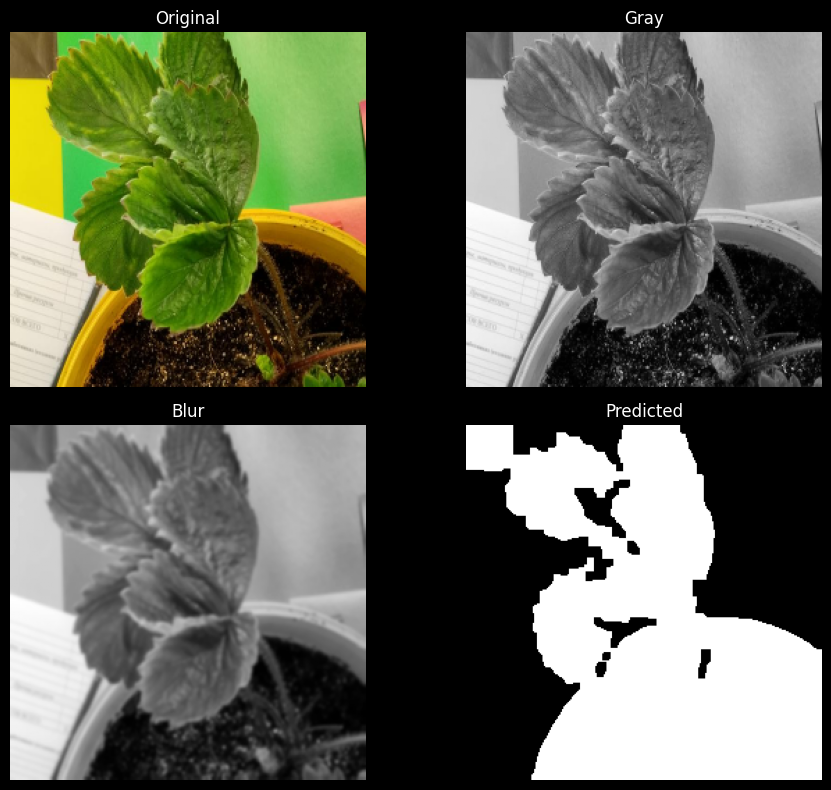

In [33]:
gray, blur, pred = segment_simple(img)
show_many([img, gray, blur, pred], ["Original", "Gray", "Blur", "Predicted"], cols=2, size=(10, 8))

## Step 8: Metrics

In [34]:
def segmentation_metrics(y_true, y_pred):
    y_true = (y_true > 0).astype(np.uint8).flatten()
    y_pred = (y_pred > 0).astype(np.uint8).flatten()

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)

    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou, "dice": dice}

metrics = segmentation_metrics(gt, pred)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

precision: 0.5993
recall: 0.8383
f1: 0.6990
iou: 0.5372
dice: 0.6990


## Step 9: Evaluate on multiple images

In [35]:
results = []
for img_path, mask_path in pairs[:50]:
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_simple(img)
    m = segmentation_metrics(gt, pred)
    results.append(m)

df = pd.DataFrame(results)
print(df.mean())

precision    0.694515
recall       0.659454
f1           0.622773
iou          0.492889
dice         0.622773
dtype: float64


# Practice Tasks

## Task 1
Change kernel size from (5,5) to (3,3) and compare results.

## Task 2
Try `cv2.THRESH_BINARY` instead of `cv2.THRESH_BINARY_INV`.

## Task 3
Test on 10 more images and compare metrics.

## Task 4
Display 3 success cases (high IoU) and 3 failure cases (low IoU).

## Task 5
Try adaptive thresholding vs Otsu thresholding.

In [36]:
# Task 1: Try different kernel size
gray, blur, pred_33 = segment_simple(img, kernel_size=(3, 3))
m33 = segmentation_metrics(gt, pred_33)
print("Kernel (3,3):", m33)

gray, blur, pred_55 = segment_simple(img, kernel_size=(5, 5))
m55 = segmentation_metrics(gt, pred_55)
print("Kernel (5,5):", m55)

Kernel (3,3): {'precision': np.float64(0.8085723493391319), 'recall': np.float64(0.7013277428370135), 'f1': np.float64(0.7511413766581486), 'iou': np.float64(0.6014623037275558), 'dice': np.float64(0.7511413816330176)}
Kernel (5,5): {'precision': np.float64(0.873119801804604), 'recall': np.float64(0.4597251339388634), 'f1': np.float64(0.6023132984990919), 'iou': np.float64(0.4309358487269246), 'dice': np.float64(0.6023133030181888)}


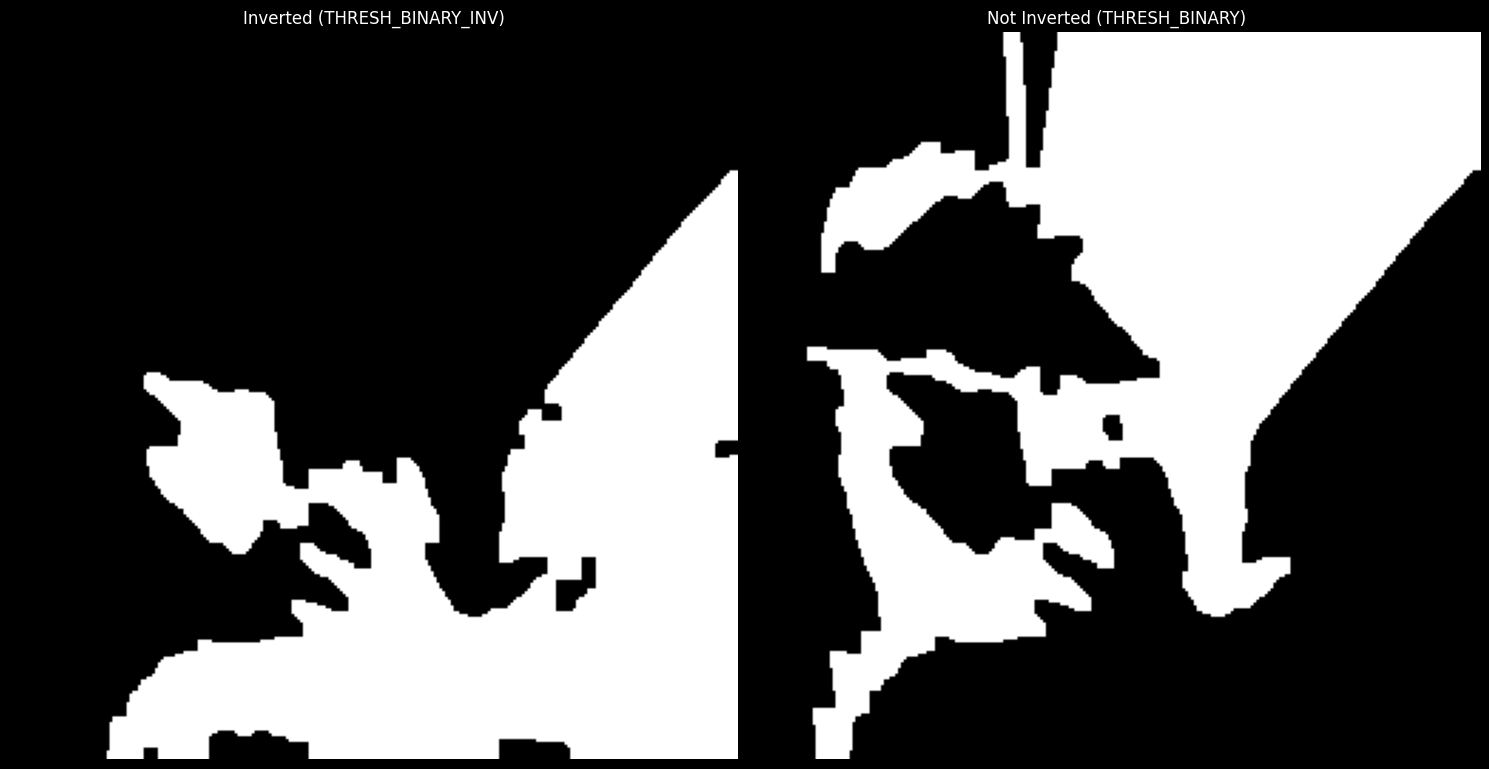

In [37]:
# Task 2: Try without inversion
gray, blur, pred_inv = segment_simple(img, invert=True)
gray, blur, pred_noinv = segment_simple(img, invert=False)

show_many([pred_inv, pred_noinv], ["Inverted (THRESH_BINARY_INV)", "Not Inverted (THRESH_BINARY)"], cols=2)

In [38]:
# Task 3: Test on 10 more images
results_10 = []
for img_path, mask_path in pairs[1:11]:
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_simple(img)
    m = segmentation_metrics(gt, pred)
    results_10.append(m)

print(pd.DataFrame(results_10).mean())

precision    0.587983
recall       0.799458
f1           0.623649
iou          0.474597
dice         0.623649
dtype: float64


Top 3 (success):


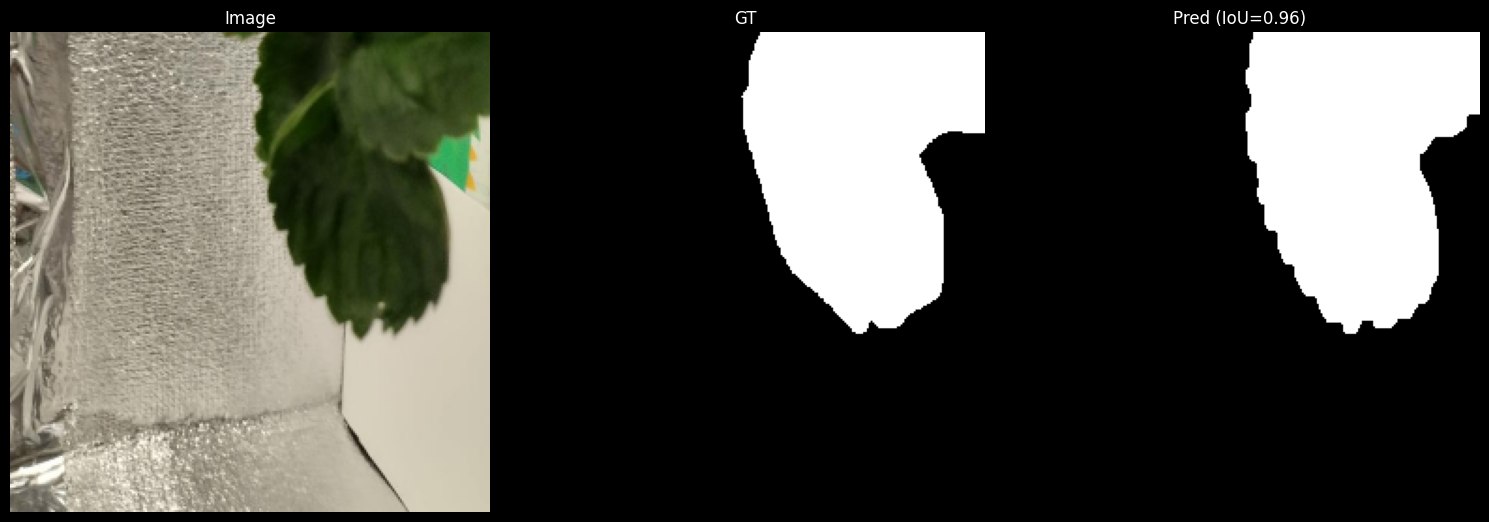

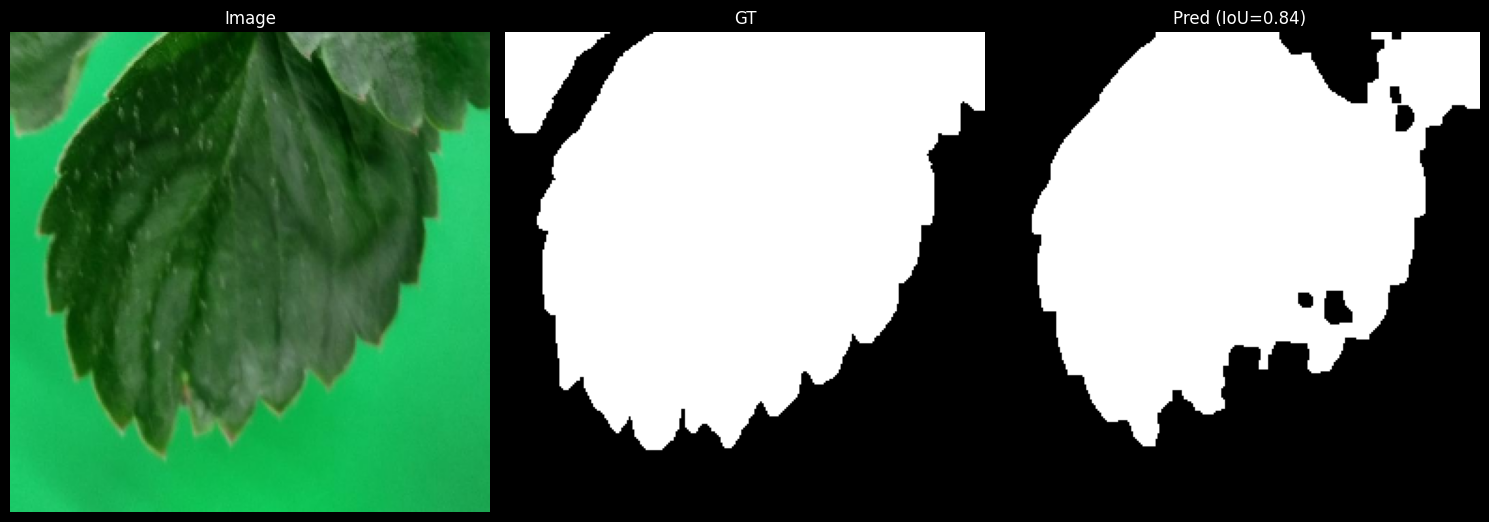

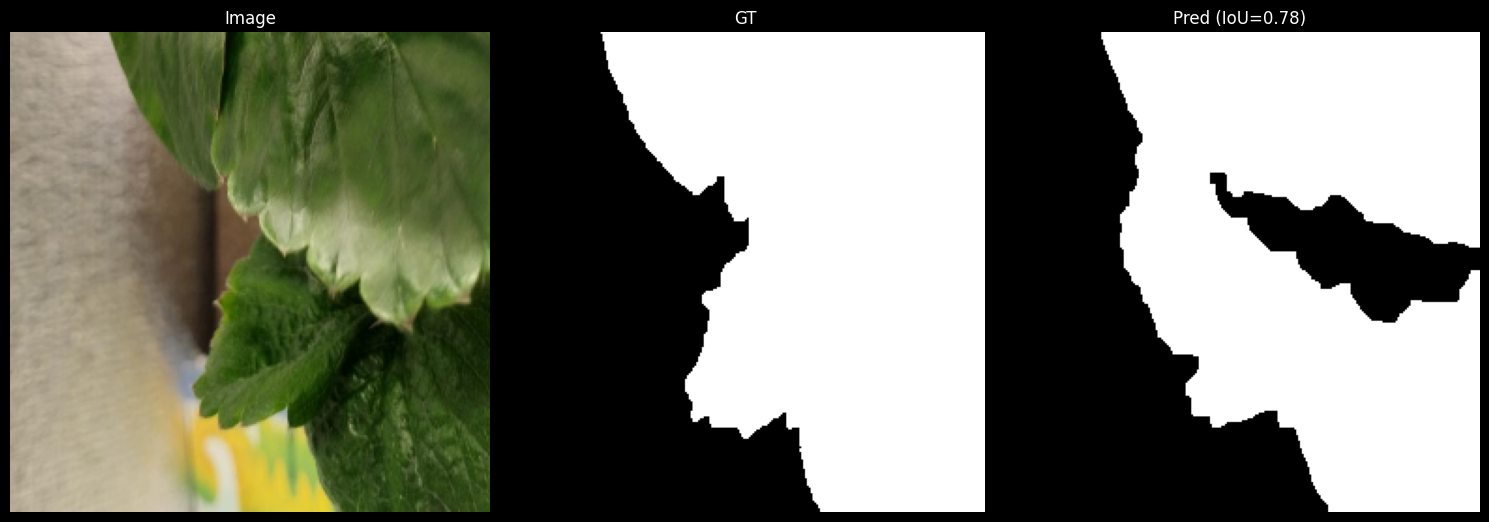

In [39]:
# Task 4: Show success and failure cases
results_all = []
for img_path, mask_path in pairs[:20]:
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_simple(img)
    m = segmentation_metrics(gt, pred)
    m["img"] = img
    m["gt"] = gt
    m["pred"] = pred
    results_all.append(m)

df_all = pd.DataFrame(results_all).sort_values("iou", ascending=False)

print("Top 3 (success):")
for i, row in df_all.head(3).iterrows():
    show_many([row["img"], row["gt"], row["pred"]], ["Image", "GT", f"Pred (IoU={row['iou']:.2f})"], cols=3)

Bottom 3 (failure):


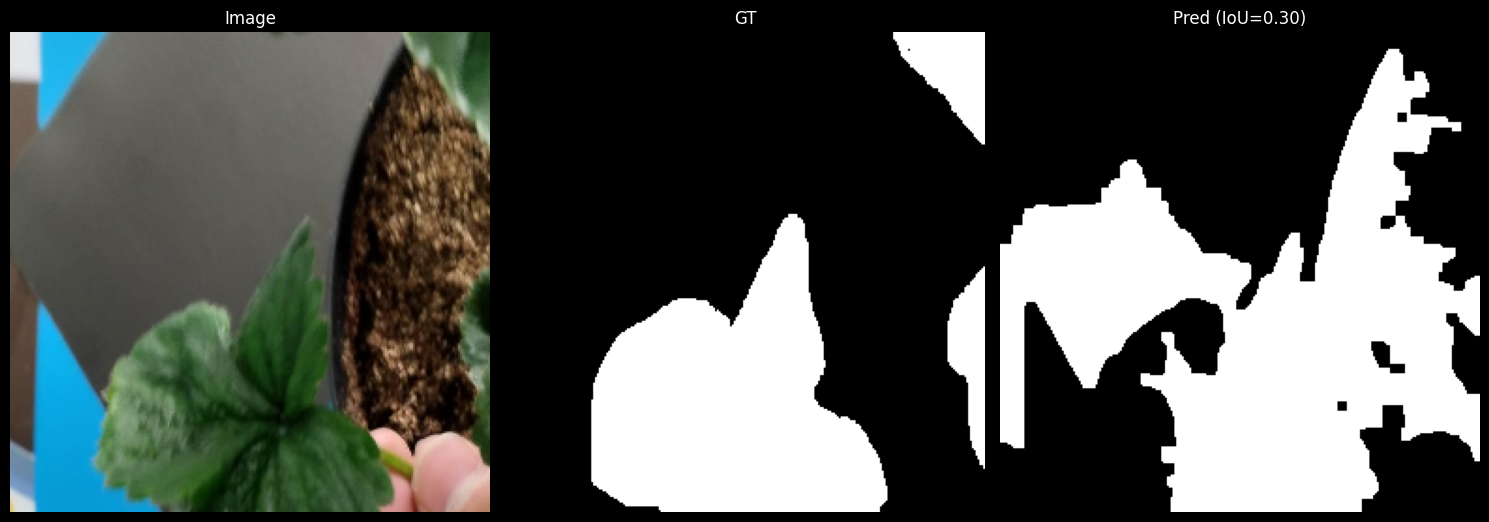

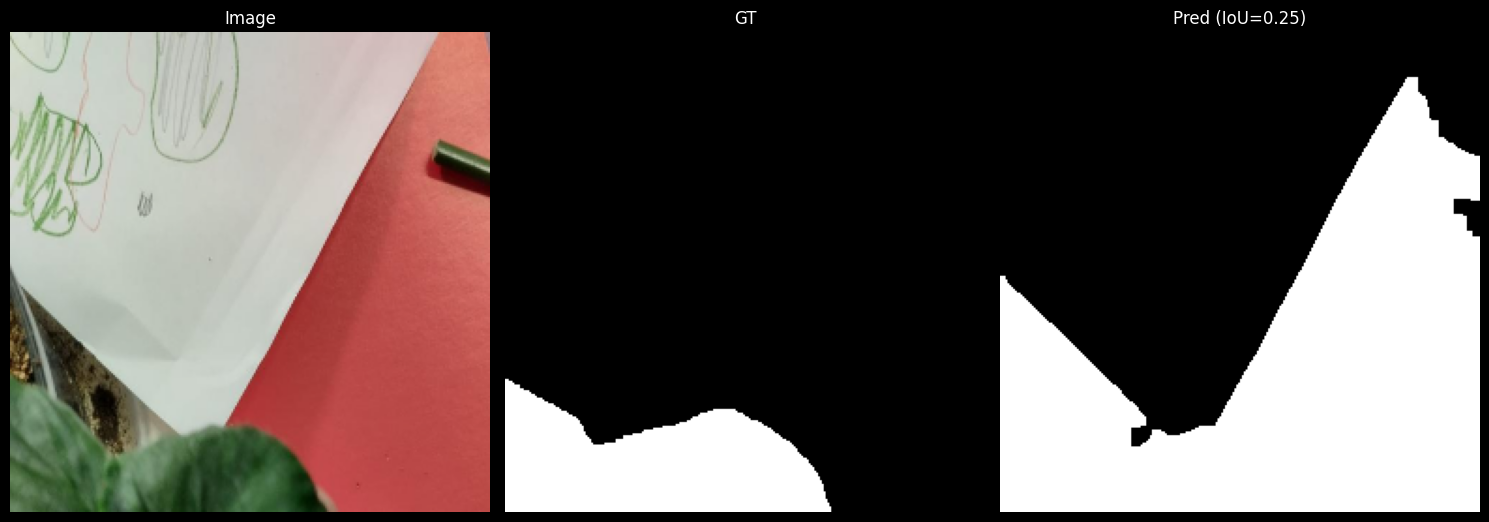

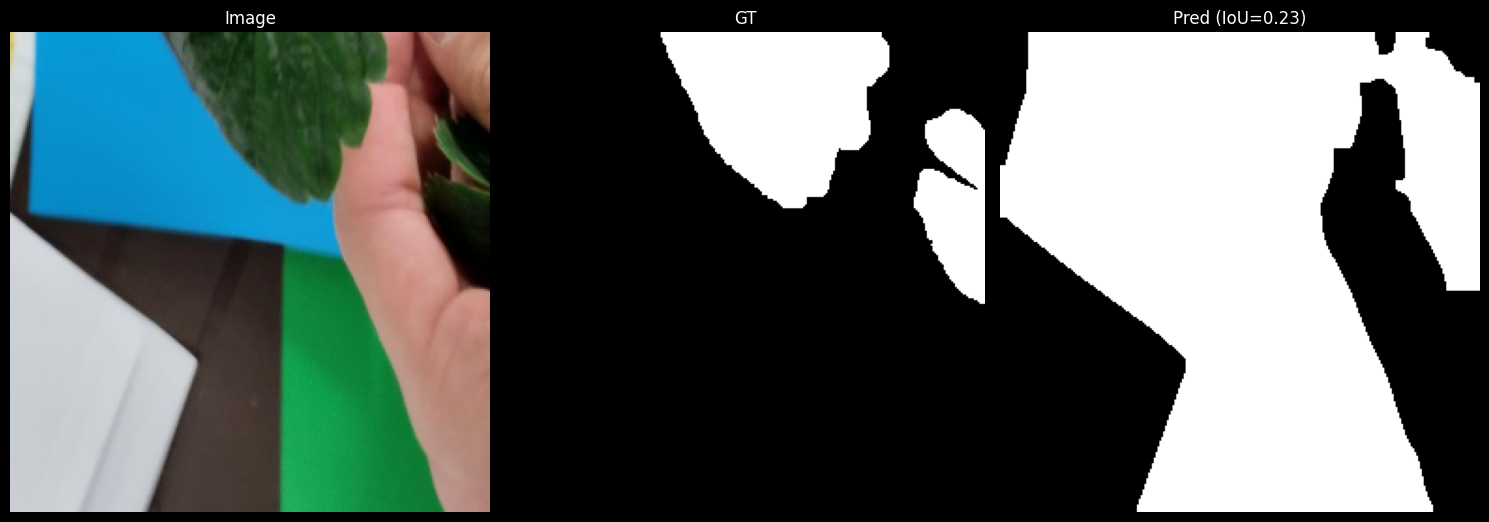

In [40]:
print("Bottom 3 (failure):")
for i, row in df_all.tail(3).iterrows():
    show_many([row["img"], row["gt"], row["pred"]], ["Image", "GT", f"Pred (IoU={row['iou']:.2f})"], cols=3)

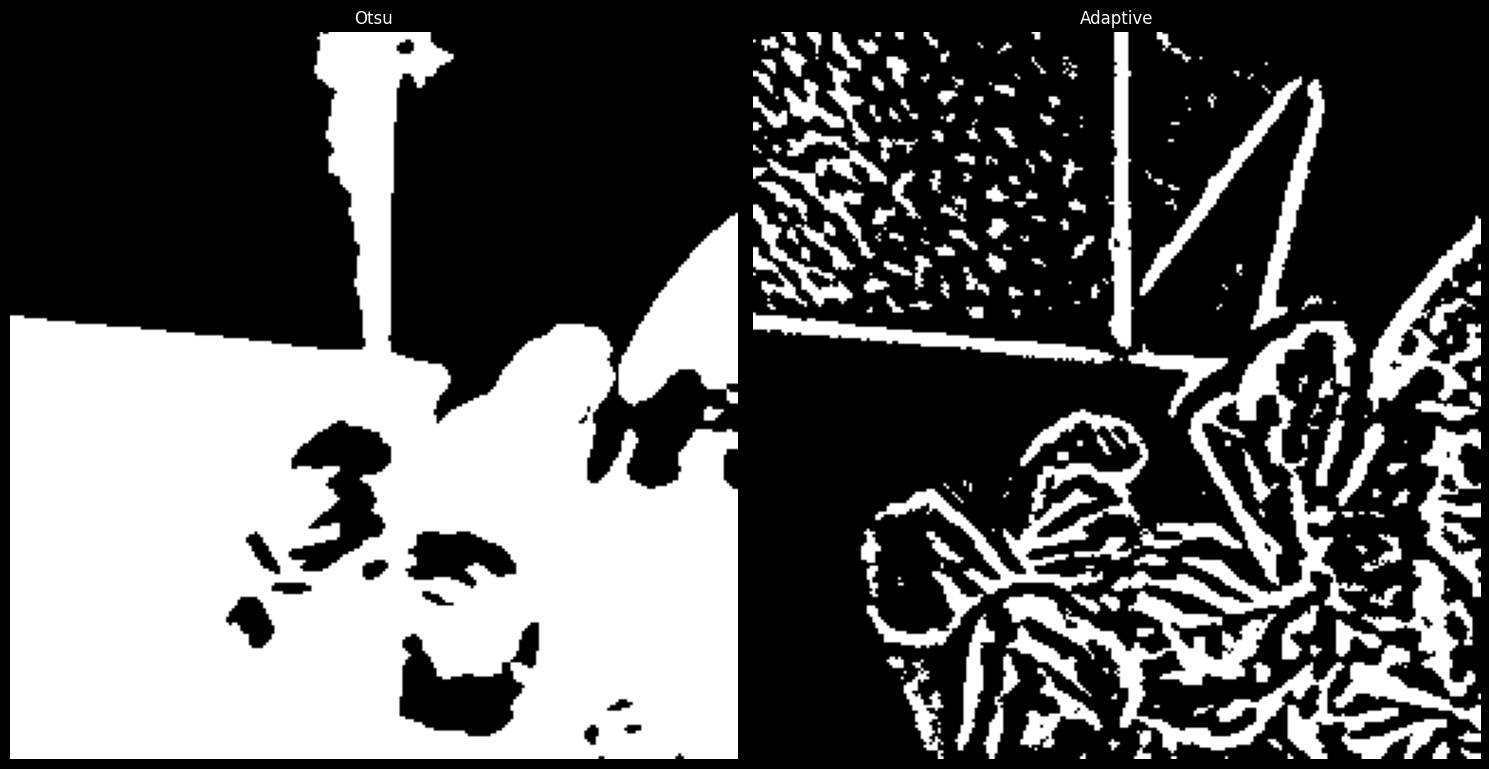

In [41]:
# Task 5: Adaptive thresholding vs Otsu
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Otsu
_, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Adaptive
adaptive = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

show_many([otsu, adaptive], ["Otsu", "Adaptive"], cols=2)